Following tutorial here: https://www.geeksforgeeks.org/machine-learning/what-is-lasso-regression/

### Step 1: Import libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

### Step 2: Sample Dataset
- Creates 500 data samples
- Uses 10 input features, out of which only 5 are truly informative
- Adds noise to simulate real-world data
- random_state ensures reproducibility
- Helps demonstrate how Lasso removes irrelevant features

In [8]:
X, y = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=15,
    random_state=42
)

### Step 3: Split Data into Training and Testing Sets

- Splits data into 80% training and 20% testing
- Training data is used to learn coefficients
- Testing data is used to evaluate generalization
- Prevents biased performance estimation

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 4: Train the Lasso Regression Model

- alpha controls the strength of L1 regularization
- Higher alpha means stronger shrinkage of coefficients
- Model learns optimal coefficients using training data
- Some coefficients may become exactly zero

In [10]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Step 5: Make Predictions and Evaluate Performance

- Uses trained model to predict outputs for test data
- Mean Squared Error measures average prediction error
- $R^2$ score measures explained variance
- Helps assess how well the model generalizes

In [11]:
y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse, r2

(262.3077665531248, 0.9428029703899435)

### Step 6: Regression Line

- Each point represents one test sample
- X-axis shows actual target values
- Y-axis shows predicted values
- Points closer to a diagonal indicate better predictions
- Spread shows the magnitude of prediction error
- Line shows regression line

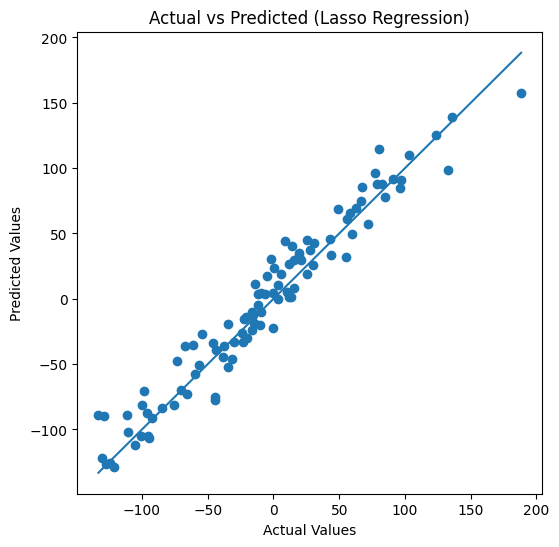

(np.float64(-133.10638332217096), np.float64(188.33138577909367))

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Lasso Regression)")
plt.show()

min_val, max_val

### Step 7: Plot Lasso Coefficients (Feature Selection)

- Each bar represents one feature’s coefficient
- Zero-height bars indicate discarded features
- Non-zero bars indicate selected important features
- Clearly visualizes Lasso’s feature selection behavior

Text(0.5, 1.0, 'Lasso Regression Coefficients')

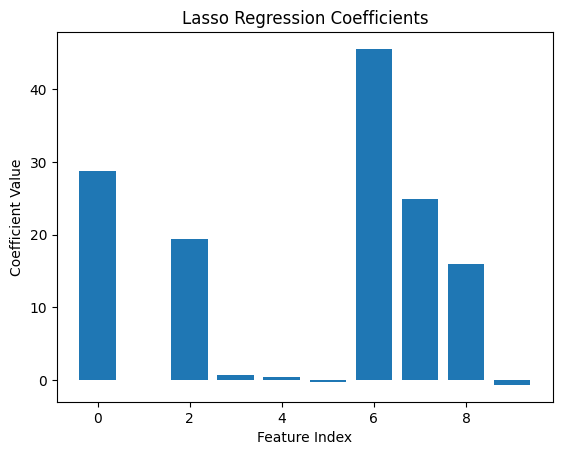

In [21]:
plt.bar(range(len(lasso.coef_)), lasso.coef_)
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")

### Step 8: Plot Effect of Regularization Strength (Lasso Path)

- Generates a range of alpha (λ) values on a logarithmic scale
- Trains a new Lasso model for each alpha value
- Stores coefficient values for every feature
- Plots how coefficients change as regularization increases
- Shows that coefficients gradually shrink and drop to zero
- Helps identify stable and important features

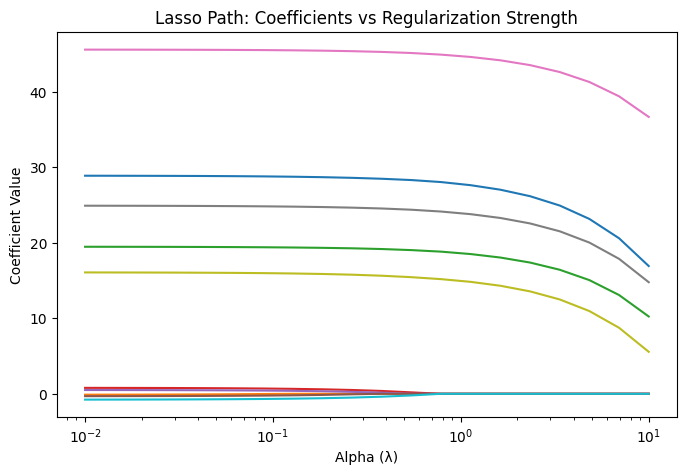

In [22]:
alphas = np.logspace(-2, 1, 20)
coefficients = []


for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    coefficients.append(model.coef_)


coefficients = np.array(coefficients)
plt.figure(figsize=(8, 5))
for i in range(coefficients.shape[1]):
    plt.plot(alphas, coefficients[:, i])
plt.xscale("log")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Path: Coefficients vs Regularization Strength")
plt.show()

- Each curve represents one feature’s coefficient in the Lasso model
- X-axis shows regularization strength (α) on a logarithmic scale
- As α increases, coefficients shrink toward zero
- Less important features drop to exactly zero
- Important features remain non-zero for longer
- It shows Lasso’s feature selection and overfitting control